In [ ]:
import h5py
f = h5py.File(r"D:\Project\NeurIPS\data\real_5025_5.h5", "r")
for key in f.keys():
    d = f[key]
    if d.shape == ():
        print(key, "= single value:", d[()])
    else:
        print(key, "shape =", d.shape)
f.close()

aoa = single value: 0
re = single value: 3750
t shape = (868,)
u shape = (868, 64, 128)
v shape = (868, 64, 128)
x shape = (64, 128)
y shape = (64, 128)


da luu anh -> mo file explore/bai2.png


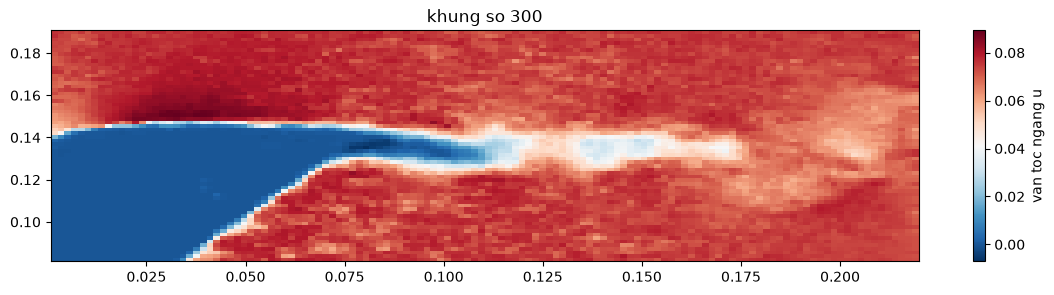

In [7]:
import h5py, numpy as np
import matplotlib.pyplot as plt

f = h5py.File(r"D:\Project\NeurIPS\data\real_5025_5.h5", "r")
u = f["u"][()]; v = f["v"][()]          # nạp cả video
x = f["x"][()]; y = f["y"][()]
f.close()

plt.figure(figsize=(14, 3))
plt.pcolormesh(x, y, u[300], cmap="RdBu_r", shading="auto")
plt.colorbar(label="van toc ngang u")
plt.title("khung so 300")
plt.savefig(r"D:\Project\NeurIPS\explore\bai2.png", dpi=110, bbox_inches="tight")
print("da luu anh -> mo file explore/bai2.png")

da luu video -> D:\Project\NeurIPS\explore\bai3_video.gif


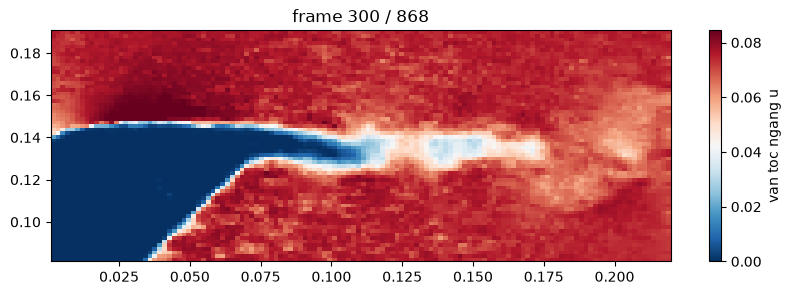

: 

In [ ]:
import os
os.makedirs(r"D:\Project\NeurIPS\explore", exist_ok=True)

import h5py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

f = h5py.File(r"D:\Project\NeurIPS\data\real_5025_5.h5", "r")
u = f["u"][()]
x = f["x"][()]; y = f["y"][()]
f.close()

vmin, vmax = np.percentile(u, [1, 99])          # chuan hoa mau de nhin ro cac vet xoay
start, n_frames, step = 300, 80, 2              # 80 khung, cach nhau 2 buoc thoi gian

fig, ax = plt.subplots(figsize=(10, 3))
mesh = ax.pcolormesh(x, y, u[start], cmap="RdBu_r", shading="auto",
                     vmin=vmin, vmax=vmax)
fig.colorbar(mesh, ax=ax, label="van toc ngang u")
title = ax.set_title("frame {}".format(start))

def update(i):
    t = start + i * step
    mesh.set_array(u[t].ravel())
    title.set_text("frame {} / {}".format(t, len(u)))
    return mesh, title

ani = FuncAnimation(fig, update, frames=n_frames, interval=100, blit=False)
out = r"D:\Project\NeurIPS\explore\bai3_video.gif"
ani.save(out, writer=PillowWriter(fps=12))
print("da luu video ->", out)